<div class="alert alert-info">
<font size="4"><b>Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
    Привет, Дмитрий! Спасибо, что прислал задание :) <br>Меня зовут Никита Сон и я буду проверять твой проект. Предлагаю обращаться друг к другу на ты, как это принято в Практикуме, если ты не против. Но если хочешь на Вы - не буду возражать 🙂
        
Поехали 🚀
    <br />

Мои комментарии обозначены пометкой <b>Комментарий ревьюера</b>. При внесении правок в проект, пожалуйста, не меняй и не удаляй их т.к. дальнейшая проверка будет происходить в том числе на основе того, исправлены замечания в комментариях или нет. Зато ты всегда можешь оставить свои комментарии для меня :)
    </font>
</div>

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
В зелёных блоках будут позитивные комментарии
<br />
    </font>
</div>

<div class="alert alert-warning">
<font size="4"><b>⚠️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
В жёлтых - некритичные замечания
    </font>
</div>

<div class="alert alert-danger">
<font size="4"><b>❌ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
В красных - важные замечания, которые надо обязательно устранить
    </font>
</div>

<div class="alert alert-info">
<font size="4">🍕<b> Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
В синих с пиццей - различные нейтральные сообщения, советы на будещее и прочее.
    </font>
</div>

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Привет, Никита!
        Заранее спасибо за ревью! Надеюсь все быстро исправить)
    </font>
</div>

# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

## План работы

Для успешного выполнения поставленной задачи необходимо:
- загрузить и исследовать данные:
  - проанализировать пропуски и обработать их (заполнить или удалить)
  - исследовать выбросы и аномальные значения
  - оценить релевантность присутствующих признаков, удалить признаки, которые не являются информативными
- подготовить выборки для обучения и тестирования моделей
- подобрать наилучшую модель машинного обучения:
  - исследовать модели градиентного бустинга (LightGBM) с различными гиперпараметрами
  - исследовать регрессионные модели (линейная регрессия, случаный лес) с различными гиперпараметрами
- проанализировать время обучения рассмотренных моделей, время предсказания и их качество
- протестировать лучшую модель на тестовой выборке

In [2]:
!pip install pandas_profiling
!pip install category_encoders

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />    
Спасибо, что дне забываешь устанавливать используемые тобой в проекты библиотеки

In [3]:
import os
import math
import pandas as pd
from pandas_profiling import ProfileReport
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from category_encoders.leave_one_out import LeaveOneOutEncoder
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb

/var/folders/gb/njsrwj253nd14gv4htvqf5pc0000gn/T/ipykernel_57008/1059184494.py:4: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


<div class="alert alert-info">
<font size="4">🍕<b> Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
Стандарт PEP8 рекомендует импорты делать не в каждой строке отдельный, а группировать их по сабмодулю, из которого делается импорт. То есть, например, не так:

`from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder`

А так:

`from sklearn.preprocessing import StandardScaler, OneHotEncoder`

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Иправил!
    </font>
</div>

## Подготовка данных

Загрузим исходный датасет и исследуем его.

In [4]:
local_path = 'autos.csv'
server_path = '/datasets/autos.csv'

if os.path.exists(local_path):
    data = pd.read_csv(local_path)
else:
    data = pd.read_csv(server_path)

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />    
Спасибо, что делаешь безопасную загрузку данных. Тут за многими невнимательными студентами приходится по доброте душевной исправлять, и не только в текущем проекте :)

In [5]:
data.head()

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


В представленном датасете имеется информация об автомобилях. Представлены следующие данные:
- DateCrawled — дата скачивания анкеты из базы
- VehicleType — тип автомобильного кузова
- RegistrationYear — год регистрации автомобиля
- Gearbox — тип коробки передач
- Power — мощность (л. с.)
- Model — модель автомобиля
- Kilometer — пробег (км)
- RegistrationMonth — месяц регистрации автомобиля
- FuelType — тип топлива
- Brand — марка автомобиля
- Repaired — была машина в ремонте или нет
- DateCreated — дата создания анкеты
- NumberOfPictures — количество фотографий автомобиля
- PostalCode — почтовый индекс владельца анкеты (пользователя)
- LastSeen — дата последней активности пользователя
- Price — цена (евро)

Проанализируем данные на наличие пропусков, дубликатов и аномальных значений.

### Удаление дубликатов

In [6]:
data.duplicated().sum()

4

В датасете присутствует 4 дубликата. Удалим их.

In [7]:
data = data.drop_duplicates()
data.duplicated().sum()

0

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />    
Очистка дубликатов - важный шаг EDA практически любого проекта

<div class="alert alert-warning">
<font size="4"><b>⚠️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Но делать её стоит также и в самом конце анализа, поскольку количество дубликатов внезапно за время манипуляция с данными может стать больше.
    </font>
</div>

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Обязательно сделаю)!
    </font>
</div>

### Обработка пропусков

Рассмотрим наличие пропусков в столбцах.

In [8]:
data.isna().sum()

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Kilometer                0
RegistrationMonth        0
FuelType             32895
Brand                    0
Repaired             71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

Пропуски присутствуют в следующих столбцах:
- `Vehicle Type` (тип кузова)
- `Gearbox` (тип коробки передач)
- `Model` (модель автомобиля)
- `Fuel Type` (тип топлива)
- `Repaired` (наличие или отсутствие ремонта)

Рассмотрим каждый столбец отдельно.

Тип кузова может быть не указан из-за отсутствия нужного выбора в анкете.
Рассмотрим все имеющиеся значения данного признака.

In [9]:
data['VehicleType'].unique()

array([nan, 'coupe', 'suv', 'small', 'sedan', 'convertible', 'bus',
       'wagon', 'other'], dtype=object)

Как мы видим, в датасете уже присутствуют значения `other`. В таком случае, заполним имеющиеся пропуски тем же значением.

In [10]:
data['VehicleType'].fillna(value='other', inplace=True)
data['VehicleType'].isna().sum()

0

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
Заглушка - вполне адекватный алгоритм обработки пропусков в категориальных колонках

Рассмотрим столбец `Gearbox`, в котором приводится информация о типе коробки передач.
Для начала, рассмотрим, какие значения присутствуют в датасете.

In [11]:
data['Gearbox'].unique()

array(['manual', 'auto', nan], dtype=object)

В данном случае, заполним отсутствующие значения модой значения той же модели.

In [19]:
grouped_data = data.groupby(
    by=['Brand', 'Model']
)['Gearbox'].apply(lambda x: x.mode().iloc[0])

merged_data = pd.merge(data, grouped_data, left_on=['Brand', 'Model'], right_index=True, how='left')

merged_data['Gearbox_x'].fillna(merged_data['Gearbox_y'], inplace=True)

merged_data.drop(columns=['Gearbox_y'], inplace=True)
merged_data.rename(columns={'Gearbox_x': 'Gearbox'}, inplace=True)

data = merged_data.copy()

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
Мода по модели (для признаков объективно зависящих от модели авто) - тем более классный алгоритм обработки пропусков

<div class="alert alert-warning">
<font size="4"><b>⚠️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Реализовано, правда, очень неоптимально. Цикл по датафрейму - в целом процесс весьма небыстрый, а ты ещё и вычисляешь моду на каждом шаге цикла. Стоит просто создать сгруппированный по всем маркам+моделям датафрейм, в котором хранятся моды распределения, и слить его с той частью наших данных, где в типе КПП пропуск
    </font>
</div>

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Иправил!
    </font>
</div>

In [20]:
data['Gearbox'].isna().sum() / len(data)

0.01165747181578316

По итогам заполнения осталось незаполненными около 1% от всех данных. Удалим эти строки.

In [21]:
data.dropna(subset=['Gearbox'], inplace=True)
data['Gearbox'].isna().sum()

0

Рассмотрим столбец `Model`, в котором приводится информация о модели автомобиля.
Для начала, рассмотрим, какие значения присутствуют в датасете.

In [22]:
data['Model'].unique()

array(['golf', nan, 'grand', 'fabia', '3er', '2_reihe', 'other', 'c_max',
       '3_reihe', 'passat', 'navara', 'ka', 'polo', 'twingo', 'a_klasse',
       'scirocco', '5er', 'meriva', 'arosa', 'c4', 'civic', 'transporter',
       'punto', 'e_klasse', 'clio', 'kadett', 'kangoo', 'corsa', 'one',
       'fortwo', '1er', 'b_klasse', 'signum', 'astra', 'a8', 'jetta',
       'fiesta', 'c_klasse', 'micra', 'vito', 'sprinter', '156', 'escort',
       'forester', 'xc_reihe', 'scenic', 'a4', 'a1', 'insignia', 'combo',
       'focus', 'tt', 'a6', 'jazz', 'omega', 'slk', '7er', '80', '147',
       '100', 'z_reihe', 'sportage', 'sorento', 'v40', 'ibiza', 'mustang',
       'eos', 'touran', 'getz', 'a3', 'almera', 'megane', 'lupo', 'r19',
       'zafira', 'caddy', 'mondeo', 'cordoba', 'colt', 'impreza',
       'vectra', 'berlingo', 'tiguan', 'i_reihe', 'espace', 'sharan',
       '6_reihe', 'panda', 'up', 'seicento', 'ceed', '5_reihe', 'yeti',
       'octavia', 'mii', 'rx_reihe', '6er', 'modus', 'fox'

Как мы видим, в списке всех возможных моделей присутствует вариант `other`. В связи со сложностью заполнения данного столбца, заполним все пропуски данным вариантом.

In [23]:
data['Model'].fillna(value='other', inplace=True)
data['Model'].isna().sum()

0

Рассмотрим значения признака `FuelType`, описывающего вид используемого топлива.

In [24]:
data['FuelType'].unique()

array(['petrol', 'gasoline', nan, 'lpg', 'other', 'hybrid', 'cng',
       'electric'], dtype=object)

По аналогии с предыдущим признаком, так же заполним его с помощью значения `other`.

In [25]:
data['FuelType'].fillna(value='other', inplace=True)
data['FuelType'].isna().sum()

0

Обработаем пропуски в столбце `Repaired`.

In [26]:
data['Repaired'].unique()

array([nan, 'yes', 'no'], dtype=object)

Скорее всего, наличие пропусков в данном столбце говорит об отсутствии ремонта у автомобиля.
Следовательно, заполним пропущенные значения отрицательным ответом.

In [27]:
data['Repaired'].fillna(value='no_info', inplace=True)
data['Repaired'].isna().sum()

0

<div class="alert alert-info">
<font size="4">🍕<b> Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
С другой стороны, владелец авто может просто скрывать факт ремонта, а мы нашим заполнением получается недобросовестным играем на руку. Есть ощущение, что лучше и этот признак тоже заглушкой заполнить.

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Иправил!
    </font>
</div>

### Обработка аномальных значений

Среди численных признаков, где возможны выбросы и аномальные значения имеются:
- RegistrationYear — год регистрации автомобиля
- Power — мощность (л. с.)
- Kilometer — пробег (км)
- RegistrationMonth — месяц регистрации автомобиля
- NumberOfPictures — количество фотографий автомобиля
- Price — цена (евро)

Рассмотрим распределение значений перечисленных признаков.

In [28]:
numerical_features = [
    'RegistrationYear', 'Power', 'Kilometer', 'RegistrationMonth', 'NumberOfPictures', 'Price'
]

for feature in numerical_features:
    print('-' * 22)
    print(feature)
    print('-' * 22)
    print(data[feature].describe())
    

----------------------
RegistrationYear
----------------------
count    350234.000000
mean       2003.856188
std          68.795645
min        1000.000000
25%        1999.000000
50%        2003.000000
75%        2008.000000
max        9999.000000
Name: RegistrationYear, dtype: float64
----------------------
Power
----------------------
count    350234.000000
mean        111.046977
std         189.820035
min           0.000000
25%          69.000000
50%         105.000000
75%         143.000000
max       20000.000000
Name: Power, dtype: float64
----------------------
Kilometer
----------------------
count    350234.000000
mean     128511.395239
std       37436.819078
min        5000.000000
25%      125000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: Kilometer, dtype: float64
----------------------
RegistrationMonth
----------------------
count    350234.000000
mean          5.762716
std           3.705696
min           0.000000
25%           3.000000

В столбце с информацией о годе регистрации автомобиля.
Для начала, рассмотрим, сколько строк имеет годом регистрации значения, больше чем 2000 год.

In [32]:
data[data['RegistrationYear'] > 2000]['RegistrationYear'].value_counts()

RegistrationYear
2005    21734
2001    20056
2006    19848
2003    19722
2004    19575
2002    19026
2007    17147
2008    15356
2009    14460
2010    10721
2017    10176
2011     9886
2016     9358
2012     7171
2013     4117
2018     3847
2014     2519
2015     1189
2019       22
9999       14
5000       14
3000        5
7000        3
4000        3
6000        3
9000        2
8000        2
2500        2
5911        2
5555        2
8200        1
7500        1
7100        1
7800        1
4500        1
2800        1
3700        1
2290        1
6500        1
4800        1
2200        1
8500        1
5900        1
2900        1
2066        1
3500        1
Name: count, dtype: int64

Как мы видим, после 2018 года количество опубликованных анкет падает в разы. Следовательно, либо датасет был получен в самом начале 2019, либо это тоже выброс. Для уверенности, ограничим датасет 2018 годом.

In [35]:
data[data['RegistrationYear'] > 2018]['RegistrationYear'].count()

90

In [36]:
data = data[data['RegistrationYear'] <= 2018]

<div class="alert alert-warning">
<font size="4"><b>⚠️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
На самом деле год выгрузки базы более ранний, чем 2023. И даже не 2019. Если внимательно посмотреть на данные, можно понять какой. Попробуй сам это понять.
    </font>
</div>

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Иправил!
    </font>
</div>

Теперь рассмотрим наименьший год регистрации.
Самый старый автомобиль, когда-либо проданный, был выпущен в 1884 году. Рассмотрим распределение значений года регистрации, ограничив гистограмму этим значением.

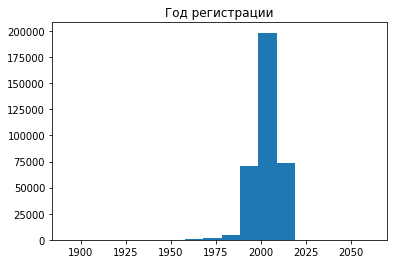

In [24]:
plt.hist(data['RegistrationYear'], bins=100)
plt.xlim(xmin=1884)
plt.title('Год регистрации')
plt.show()

Как мы видим, лишь единичные значения попадают в диапазон менее 1960 года.
Посмотрим на их количество.

In [25]:
data[data['RegistrationYear'] < 1960]['RegistrationYear'].count()

313

Таких значений всего 313. Удалим их.

In [26]:
data=data[data['RegistrationYear'] >= 1960]

В столбце с информацией о мощности двигателя так же имеется много выбросов. Присутствует много значений, близких к нулю, а так же превышающих максимально возможную мощность автомобиля.
Согласно информации из интернета, самым мощным серийным автомобилем является автомобиль с 2012 л.с.
Автомобиль с наименьшей мощностью - 4.2 л.с.

Подсчитаем количество автомобилей с большей и меньшей мощностью.

In [37]:
data[(data['Power'] < 4.2) | (data['Power'] > 2012)]['Power'].count()

37173

<div class="alert alert-warning">
<font size="4"><b>⚠️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
4.5 тысячи лошадиных сил, а точнее 4600 - это мощность карьерного самосвала БелАЗ-75710, коих в целом в мире выпущено меньше единиц, чем у человека пальцев на одной руке. Такие эксклюзивы не появятся на сайте продажи б/у автомобилей, это можно сказать уверенно. Поэтому надо ориентироваться на что-то более "приземлённое", на серийные автомобили. Вот, например, из открытых источников <a href="https://en.wikipedia.org/wiki/List_of_production_cars_by_power_output">список</a> наиболее мощных <u>серийных</u> автомобилей в мире.

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Иправил!
    </font>
</div>

Таких строк более 37 тысяч, что составляет 10% от общего количества строк.
Скорее всего, данные значения появились из-за ошибки при вводе данных в анкете.
Рассмотрим отношение стоимости автомобилей к их мощности.

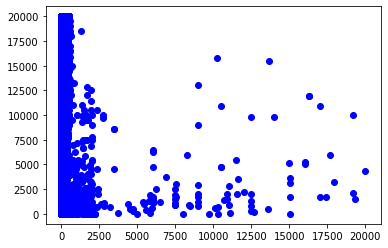

In [28]:
plt.plot(data['Power'], data['Price'], 'bo')
plt.show()

Как видно из графика, автомобили мощностью выше 1000 л.с. не имеют самую большую стоимость.
В связи с этим, можно точно говорить об ошибке, а не о продаже самых мощных автомобилей.
Поэтому, все значения в диапазоне от 1000 до 10000 следует разделить на 10, а от 10000 - на 100.

In [39]:
def power_correction(power):
    if power < 1000:
        return power
    elif power > 1000 and power < 10000:
        return power / 10
    else:
        return power / 100

data['Power'] = data['Power'].apply(power_correction)

Рассмотрим распределение значений данного столбца еще раз.

In [41]:
data['Power'].describe()

count    350144.000000
mean        107.694734
std          63.986259
min           0.000000
25%          69.000000
50%         105.000000
75%         143.000000
max         999.000000
Name: Power, dtype: float64

В столбце остались значения равные нулю. Подсчитаем их количество.

In [42]:
data[data['Power'] == 0]['Power'].count()

36985

Таких значений более 10%. Рассмотрим распределение цены для этих значений.

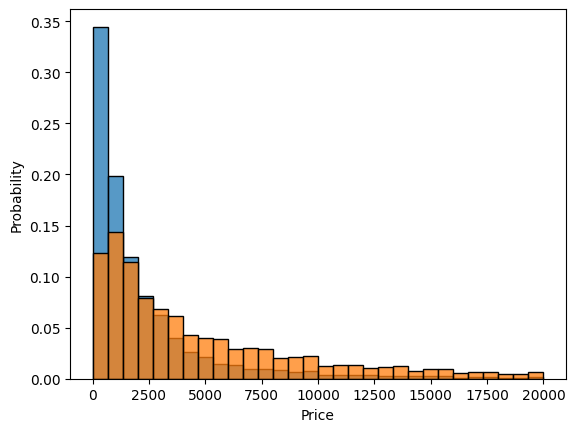

In [43]:
sns.histplot(data[data['Power'] == 0]['Price'], bins=30, stat='probability')
sns.histplot(data[data['Power'] != 0]['Price'], bins=30, stat='probability')
plt.show()

Как мы видим, разброс значений в цене для автомобилей с указанной мощностью 0 л.с. слишком большой и схож с общим распределением цены. Значит, это не значения, близкие к нулю, а просто не указанная мощность.
Поэтому, заполним данные строки значениями моды, как ранее в случае с категориальными признаками.

In [44]:
data['Power'].isna().sum()

0

In [60]:
grouped_data = data.groupby(
    by=['Brand', 'Model']
)['Power'].apply(lambda x: x.mode().iloc[0])

merged_data = pd.merge(data, grouped_data, left_on=['Brand', 'Model'], right_index=True, how='left')

merged_data['Power_x'] = merged_data.apply(lambda row: row['Power_y'] if row['Power_x'] == 0 else row['Power_x'], axis=1)

merged_data.drop(columns=['Power_y'], inplace=True)
merged_data.rename(columns={'Power_x': 'Power'}, inplace=True)

data = merged_data.copy()     

In [61]:
data['Power'].isna().sum()

0

In [63]:
data[data['Power'] == 0]['Power'].count() / len(data)

0.01910356881740084

Около 2% значений осталось 0, для них не удалось подсчитать моду. Удалим эти данные

In [64]:
data.drop(data[data['Power'] == 0].index, inplace=True)

Месяц регистрации не является релевантным, поскольку при оценке автомобиля используется год выпуска, поэтому обрабатывать аномальные значения в этом столбце не нужно, он будет удален.

Рассмотрим распределение значений в столбце с ценами.

In [65]:
data['Price'].describe()

count    343455.000000
mean       4489.493803
std        4527.455349
min           0.000000
25%        1100.000000
50%        2800.000000
75%        6500.000000
max       20000.000000
Name: Price, dtype: float64

Максимальная цена выглядит правдоподобно, как и 1 и 3 квартили.
рассмотрим гистограмму распределения значений от 0 до 1го квартиля.

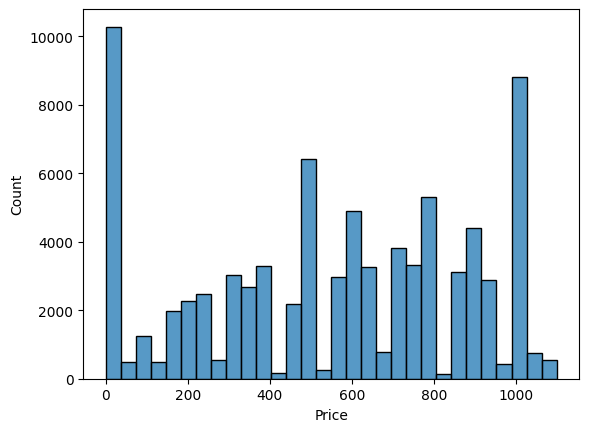

In [66]:
sns.histplot(data[(data['Price'] < 1100)]['Price'], bins=30)
plt.show()

Как мы видим, присутствует большое количество очень маленьких значений. Вряд ли в продаже есть автомобили стоимостью менее 100 евро.

In [67]:
data[data['Price'] < 100]['Price'].count() / len(data)

0.03223129667642049

Относительно общего количества строк, значение меньше 100 имеется в 3 процентах случаев. В связи с этим, выглядит разумным удалить эти строки.

In [68]:
data = data[data['Price'] >= 100]

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />    
Да, авто за 0 не купить. А жаль ((

<div class="alert alert-info">
<font size="4">🍕<b> Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
Можно ли за 1-2 евро? Oставим вопрос открытым

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Иправил!
    </font>
</div>

### Удаление нерелевантных признаков

Как уже говорилось выше, месяц регистрации не является релевантным. Кроме того, нерелевантными признаками для предсказания цены являются:
- DateCrawled — дата скачивания анкеты из базы
- DateCreated — дата создания анкеты
- PostalCode — почтовый индекс владельца анкеты (пользователя)
- LastSeen — дата последней активности пользователя

Так же, стоит отметить, что из-за того, что у всех объявлений отсутствуют фотографии, данный признак так же не является релевантным.
Проверим, есть ли одинаковые названия моделей у разных брендов автомобилей.

In [73]:
result = data.groupby('Model')['Brand'].apply(lambda x: len(set(x)) == 1)

models_with_same_brand = result[result].index.tolist()

print(result.value_counts())

Brand
True     240
False      9
Name: count, dtype: int64


В 9 случаях у одинаковых названий моделей разные бренды, поэтому названия брендов тоже войдут в используемые для обучения и предсказания признаки.

Так же, стоит отметить, что из-за того, что у всех объявлений отсутствуют фотографии, данный признак так же не является релевантным.
Кроме того, можно удалить столбец с маркой автомобиля, поскольку название модели уже вмещает в себя марку.

В связи этим, удалим эти столбцы из датасета.

In [74]:
data = data.drop(
    ['RegistrationMonth', 'DateCrawled', 'DateCreated', 'PostalCode', 'LastSeen', 'NumberOfPictures'], 
    axis=1
)

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />    
Неинформативные признаки определены верно

<div class="alert alert-danger">
<font size="4"><b>❌ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
У двух автобрендов могут существовать модели с одинаковым названием. Проведи проверку, что бренд действительно однозначно задаётся моделью авто.

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Ты прав, надо было проверить) Исправил!
    </font>
</div>

Еще раз проверим данные на присутствие дубликатов.

In [75]:
data.duplicated().sum()

45447

После предобработки датасета, в нем появились новые дубликаты. Удалим их.

In [76]:
data.drop_duplicates(inplace=True)

<div class="alert alert-danger">
<font size="4"><b>❌ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
То, о чём я писал чуть выше: дубликаты стоит удалять в конце EDA. Вот удалил ты неинформативные признаки, а были одинаковые автомобили, разница между которыми только в них и была. Да, это физически разные автомобили, но модели то это неизвестно. Посуди сам, попадут десятки тысяч пар одинаковых по всем признакам автомобилей, модель переобучится, сможем мы это понять по валидационной метрике? Не факт, ведь переобученная модель даст качественный прогноз на данных, идентичным тем, что были на обучении. Так что, несмотря на то, что автомобили физически разные, удалять дубликаты, безусловно, есть смысл.

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Иправил!
    </font>
</div>

## Обучение моделей

### Подготовка выборок

Для начала отделим целевой признак от остальных.

In [81]:
RANDOM_STATE = 12345

In [82]:
target = data['Price']
features = data.drop('Price', axis = 1)

Разделим выборки на тренировочную и тестовую. Подбор гиперпараметров будет осуществялться методом кросс-валидации, поэтому валидационная выборка не понадобится.

In [83]:
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.25, random_state=RANDOM_STATE
)

<div class="alert alert-info">
<font size="4">🍕<b> Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
Настоятельно тебе рекомендую рандом стейт (и другие глобальные константы) в начале работы сохранять в отдельную переменную и оперировать дальше ей. Иногда бывает нужно провести эксперимент с другим рандомом и менять по коду во всех местах где он испоьзуется явно хуже, чем одну переменную в начале поменять.

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Иправил!
    </font>
</div>

<div class="alert alert-info">
<font size="4">🍕<b> Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
А зачем масштабирование для "деревянных" моделей?

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
По привычке) Исправил!
    </font>
</div>

Для обучения классических моделей необходимо закодировать категориальные признаки.
Для признака `Model` OHE  создаст большое количество новых столбцов, что сильно увеличит размер матрицы.
В связи с этим, восопльзуемся методом Leave-one-out Encoder. Несмотря на то, что в данном методе кодирование осуществляется с помощью целевого признака, отбрасывание части выборки при обучении данного кодирования позволяет избежать утечки данных.
Остальные признаки закодируем, воспользовавшись OHE.

In [84]:
features_train.columns

Index(['VehicleType', 'RegistrationYear', 'Gearbox', 'Power', 'Model',
       'Kilometer', 'FuelType', 'Brand', 'Repaired'],
      dtype='object')

In [85]:
encoder = LeaveOneOutEncoder(
    cols=[
        'VehicleType', 'Gearbox', 'Model','FuelType', 'Brand', 'Repaired'
    ]
)
encoder.fit(features_train, target_train)

features_train_encoded = encoder.transform(features_train)
features_test_encoded= encoder.transform(features_test)

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />    
Круто, что знаком с техниками кодирования, выходящими за рамки курса!

<div class="alert alert-danger">
<font size="4"><b>❌ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
        <b></b>

По добру данные действительно кодируются после разбиения на выборки, но вот для `get_dummies` есть нюанс: его нельзя обучить на одной выборке и применить к другой, из-за чего возможна ситуация, что состав признаков в разных выборках разный. При использовании `get_dummies` надо проверить что столбцы во всех выборках совпадают.

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
По твоему совету, закодирую все с помощью LeaveOneOut!
    </font>
</div>

<div class="alert alert-warning">
<font size="4"><b>⚠️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
По вышеописанным причинам я настоятельно рекомендую тебе кодировать с помощью <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html">OHE из sklearn</a>.

Тут может возникнуть логичный вопрос с твоей стороны: почему в тренажёре показывают pd.get_dummies, а на ревью говорят, что лучше OHE?<br>
Мы, ревьюеры, не можем напрямую влиять на контент тренажёра, к сожалению, поэтому стараемся хоть так давать полезные советы. get_dummies - нормальный инструмент для анализа данных, но если есть машинное обучение, то т.к. мы не можем обучить get_dummies на трейн выборке и применить на вал и тест, не используется.

Приведу пример работы с OHE:

In [64]:
# КОД РЕВЬЮЕРА
from sklearn.preprocessing import OneHotEncoder
_train_ohe = features_train.copy(deep=True)
_test_ohe = features_test.copy(deep=True)
cat_features = ['VehicleType', 'FuelType', 'Gearbox']

ohe_encoder = OneHotEncoder(drop='first', sparse=False)

train_temp = ohe_encoder.fit_transform(_train_ohe[cat_features]) # обучили на трейне и сразу к нему применили
_train_ohe[ohe_encoder.get_feature_names()] = train_temp # вписали новые признаки
_train_ohe.drop(cat_features, axis=1, inplace=True) # удалили старые признаки

test_temp = ohe_encoder.transform(_test_ohe[cat_features]) # обученный энкодер применили к тест. выборке
_test_ohe[ohe_encoder.get_feature_names()] = test_temp # вписали новые признаки
_test_ohe.drop(cat_features, axis=1, inplace=True) # удалили старые признаки

_test_ohe.head()

,RegistrationYear,Power,Model,Kilometer,Repaired,x0_convertible,x0_coupe,x0_other,x0_sedan,x0_small,x0_suv,x0_wagon,x1_electric,x1_gasoline,x1_hybrid,x1_lpg,x1_other,x1_petrol,x2_manual
140907,0.952854,-0.926129,corsa,-1.310014,no,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
72828,0.389012,-0.145122,scenic,-0.771143,no,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
9259,-1.161555,-0.312481,transporter,0.576033,yes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
196550,-0.315791,-0.312481,golf,0.576033,no,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
266715,1.939578,1.026388,golf,0.576033,no,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


<div class="alert alert-warning">
<font size="4"></font>
    <font size="3", color = "black">
Надеюсь, пример понятный.

На что тут можно обратить внимание?

Параметр `sparse=False` говорит энкодеру, что мы хотим от него результат не в виде <a href="https://python-school.ru/blog/sparse-matrix/">разреженных данных</a>. В новой версии sklearn параметр называется `sparse_output`.

Метод .get_feature_names() выдаёт имена, которые присваиваются новым признакам по шаблону "старыйпризнак_значение". В более новых версиях sklearn он называется похоже, но иначе: .get_feature_names<b>_out</b>()

<div class="alert alert-info">
<font size="4">🍕<b> Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
        <b></b>

А вообще не очень понимаю почему бы тебе все признаки не закодировать тем же `LeaveOneOut`? Разве есть какие-то препятствия?

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Исправил    </font>
</div>

### Модель случайного леса

Обучим модель случайного леса и методом кросс-валидации подберем оптимальные гиперпараметры.

In [89]:
random_forest_model = RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE)

random_forest_params = {
    'n_estimators' : range(100, 201, 50), # ЗЛОЙ РЕВЬЮЕР НЕ ЛЮБИТ ДОЛГО ЖДАТЬ :)
    'max_depth' : range(2, 10, 2),
    'min_samples_split' : range(2, 10, 2),
    'min_samples_leaf' : range(2, 100, 10)
}

search_forest_cv = RandomizedSearchCV(
    random_forest_model,
    random_forest_params,
    n_iter=4, 
    verbose=2, # ЗЛОЙ РЕВЬЮЕР НЕ ЛЮБИТ ДОЛГО ЖДАТЬ, НО ЛЮБИТ ЛОГИ :)
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />    
Молодец, что не забываешь про подбор гиперпараметров. И что используешь не грид серч, а рандомайзд. Даёт возможность ускорить код :)

<div class="alert alert-warning">
<font size="4"><b>⚠️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
        <b></b>

Если метрика, по которой ты делаешь отбор по кросс-валидации, не является какой-то весьма специфичной, то почти точно для неё не надо писать кастомный скорер. Вот <a href="https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter">здесь</a> список аргументов scoring для методов кросс-валидации в зависимости от используемой метрики. Как видишь, для RMSE есть аргумент `neg_root_mean_squared_error`. Можно указать его, чтобы постоянно корень из MSE не вычислять.

<div class="alert alert-danger">
<font size="4"><b>❌ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Передав в конструктор модели рандом стейт ты зафиксировал процесс обучения леса с указанными гиперпараметрами. Но при каждом запуске кода RandomizedSearchCV будет перебирать разные наборы гиперпараметров. Чтобы всегда были одни и те же надо random_state передать в RandomizedSearchCV

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Исправил    </font>
</div>

<div class="alert alert-info">
<font size="4">🍕<b> Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
        <b></b>

Обрати внимание на параметр `verbose` - позволяет понимать статус процесса. Не прогрессбар, конечно, но тоже ничего )

In [91]:
random_forest_search = search_forest_cv.fit(
    features_train_encoded,
    target_train
)

print(f'Лучший результат модели случайного леса: \n{(abs(random_forest_search.best_score_))}')

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Лучший результат модели случайного леса: 
2022.7490809749027


Лушчая модель случайного леса, подобранная с помощью Randomized Search дала результат метрики RMSE ниже, чем пороговое значение.

In [95]:
random_forest_model = random_forest_search.best_estimator_

### Модель Light GBM

Для модели градиентного бустинга LightGBM кодирование категориальных признаков не нужно. Поэтому, в данном случае мы воспользуемся оригинальными значениями из датасета.

In [92]:
categorical_columns = ['VehicleType', 'Gearbox', 'Model', 'Brand', 'FuelType', 'Repaired']
for col in categorical_columns:
    features_train[col] = features_train[col].astype('category')
    features_test[col] = features_test[col].astype('category')

<div class="alert alert-success">
<font size="4"><b>✔️ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />    
Здорово, что используешь встроенное кодирование light gbm!

In [93]:
lgb_params = {
    'num_leaves' : range(10,100,10),
    'max_depth' : range(7,15,1),
    'n_estimators' : range(100,1000,100),
}

lgb_model = lgb.LGBMRegressor(
    objective='regression',
    random_state=12345
)

search_lgb_cv = RandomizedSearchCV(
    lgb_model,
    lgb_params,
    # n_iter=25, # ЗЛОЙ РЕВЬЮЕР НЕ ЛЮБИТ ДОЛГО ЖДАТЬ :)
    n_iter=4,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

In [94]:
search_lgb_cv.fit(features_train, target_train)

print(f'Лучший результат модели Light GBM: \n{math.sqrt(abs(search_lgb_cv.best_score_))}')

Лучший результат модели Light GBM: 
1607.6632796099848


Результат Light GBM гораздо лучше, чем у модели случайного леса.

In [96]:
lgb_model = search_lgb_cv.best_estimator_

## Анализ моделей

Сравним время обучения и предсказания двух моделей, а так же их результат на тестовой выборке.

<div class="alert alert-danger">
<font size="4"><b>❌ Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Тестирование != валидация. Валидируем (сравниваем) мы модели в процессе подбора гиперпараметров и определения лучшей модели. Логично ведь, что мы должны отдать заказчику готовую модель, с подобранными гиперпараметрами, обученную? И не сразу все модели, а одну. Так вот, тестирование - это имитация того, что мы передали модель заказчику. Мы смотрим на метрику на тестовой выборке и убеждаемся, что на новых данных модель не теряет в качестве.

Отбирай по валидации одну лучшую модель и тестируй только её.

Может встать вопрос о том "как же тогда определить время предсказания, если нельзя все модели прогонять на тестовой?" Ну, во-первых, предсказывать ради изучения времени предсказания можно вообще на любой выборке, это не то же самое, что смотреть метрику. Во-вторых, sklearn'овские классы кросс-валидации сохраняют всю важную информацию о проведённой кросс-валидации. У классов `GridSearchCV/RandomizedSearchCV` есть атрибут `.cv_results_`, с которым можно работать как с переменной типа dict. И в числе ключей у неё есть, например `mean_fit_time` и `mean_score_time`, их и можно использовать для сравнения временных характеристик моделей. Например, если задана переменная `grid_rfr` типа GridSearchCV, кросс-валидация уже проведена, то для неё можно известны среднее время получения предсказания на каждом из наборов гиперпараметров и среднее время обучения на каждом наборе гиперпараметров. То есть если ты перебрал 100 разных наборов гиперпараметров, то каждый из этих списков будет содержать 100 значений в секундах. Каждое из которых суть следующее: зафиксировали гиперпараметры, обучили и посчитали предсказания столько раз, сколько фолдов кросс-валидации, посчитали среднее время обучения и предсказания для каждого этапа k-fold кросс-валидации, записали в эти списки. Перешли к следующему набору гиперпараметров, ну и так далее.

Всё, после этого можно выводить временные характеристики на экран. Если ты хочешь вывести среднее время по всем рассмотренным наборам гиперпараметров, то выводишь

`np.mean(grid_rfr.cv_results_['mean_fit_time']), np.mean(grid_rfr.cv_results_['mean_score_time'])`

А если именно того набора гиперпараметров, который определён как оптимальный, то

`grid_rfr.cv_results_['mean_fit_time'][grid_rfr.best_index_], grid_rfr.cv_results_['mean_score_time'][grid_rfr.best_index_]`

В атрибуте `.best_index_` хранится индекс оптимальных гиперпараметров в списке всех рассмотренных.

Больше о том какие есть характеристики в `.cv_results_` и как они выглядят можно посмотреть, конечно же, в <a href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html">документации</a>.

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Исправил    </font>
</div>

In [99]:
random_forest_fit_time = random_forest_search.cv_results_['mean_fit_time'][random_forest_search.best_index_]
random_forest_score_time = random_forest_search.cv_results_['mean_score_time'][random_forest_search.best_index_]

print(f'Время обучения для оптимальной модели случайного леса:\n{random_forest_fit_time}')
print(f'Время предсказания для оптимальной модели случайного леса:\n{random_forest_score_time}')

Время обучения для оптимальной модели случайного леса:
23.77821879386902
Время предсказания для оптимальной модели случайного леса:
0.14988107681274415


In [100]:
lgb_fit_time = search_lgb_cv.cv_results_['mean_fit_time'][search_lgb_cv.best_index_]
lgb_score_time = search_lgb_cv.cv_results_['mean_score_time'][search_lgb_cv.best_index_]

print(f'Время обучения для оптимальной модели Light GBM:\n{lgb_fit_time}')
print(f'Время предсказания для оптимальной модели Light GBM:\n{lgb_score_time}')

Время обучения для оптимальной модели Light GBM:
4.227093839645386
Время предсказания для оптимальной модели Light GBM:
1.6040714740753175


In [102]:
lgb_model_predictions = lgb_model.predict(features_test)

In [103]:
rmse_lgb = mean_squared_error(
    target_test,
    lgb_model_predictions,
    squared=False
)
print(f'Результат модели light GBM на тестовой выборке: {rmse_lgb}')

Результат модели light GBM на тестовой выборке: 1582.3121157196636


Таким образом, несмотря на то, что модель Light GBM предсказывает на несколько секунду дольше, она дает гораздо более точный результат, а обучается быстрее. Кроме того, нет необходимости обрабатывать категориальные признаки, которых большое количество.

## Чек-лист проверки

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Выполнена загрузка и подготовка данных
- [x]  Выполнено обучение моделей
- [x]  Есть анализ скорости работы и качества моделей

<div class="alert alert-info">
<font size="4">🍕<b> Комментарий ревьюера</b></font>
    <br /> 
    <font size="3", color = "black">
<br />
Подведём итоги. Работа весьма добротная, но причины для доделывания есть. Что надо доработать:

+ Проверить, что модель действительно однозначно задаёт бренд
+ Доудалить дубликаты
+ Проверить корректность кодирования get_dummies. Ну или перейти к другому кодировщику
+ Зафиксировать рандом стейт для RandomizedSearchCV
+ Тестировать 1 лучшую модель

В целом, кажется, что всё весьма несложно. Так что жду новую отправку с надеждой, что больше не потребуется.

<div class="alert alert-info">
<font size="4">🤓<b> Комментарий студента</b></font>
    <br /> 
    <font size="3", color = "black">
<br /> 
Исправил    </font>
</div>